In [1]:

%config InlineBackend.figure_format = 'retina'


In [2]:
from common import *

default figsize: (3.3339558599695587, 2.0604980384530722)


In [3]:
sizes = ["0.6B", "1.7B", "4B"]
css = ["32"]
model_labels = [f"{s}-{cs}" for cs in css for s in sizes]
models = [f"Qwen3-{label}" for label in model_labels]


def load_model(model_name):
    """Load trace data for a model."""
    return read_trace(f"{model_name}/1.csv")

In [4]:
# Load data for all models
dfs = {model: load_model(model) for model in models}

In [5]:
# Reuse the match_begin_end_events function from time_breakdown.ipynb
def match_begin_end_events(df, begin_type, end_type, event_type, end_cols=[], by_cols=[]):
    """Match begin and end events and calculate durations."""
    end_cols_list = ['timestamp_us'] + [c for c in end_cols if c in df.columns] + [c for c in by_cols if c in df.columns]
    begin_cols_list = ['timestamp_us'] + [c for c in by_cols if c in df.columns]
    ends = df[df['type'] == end_type][end_cols_list]
    begins = df[df['type'] == begin_type][begin_cols_list].rename(columns={'timestamp_us': 'begin_timestamp'})
    
    merged = pd.merge_asof(
        ends, begins,
        left_on='timestamp_us', right_on='begin_timestamp',
        by=by_cols if by_cols else None,
        direction='backward'
    )
    
    merged = merged.rename(columns={'timestamp_us': 'end_timestamp'})
    merged['duration_us'] = merged['end_timestamp'] - merged['begin_timestamp']
    merged['event_type'] = event_type
    return merged

In [6]:
# Extract checkpoint times for each model
checkpoint_data = {}
for model in models:
    checkpoint_df = match_begin_end_events(
        dfs[model], 'CheckpointBegin', 'CheckpointComplete', 'checkpoint', end_cols=['count']
    )
    checkpoint_df['model'] = model
    checkpoint_data[model] = checkpoint_df

checkpoint_all = pd.concat(checkpoint_data.values(), ignore_index=True)
checkpoint_all['duration_ms'] = checkpoint_all['duration_us'] / 1000

# Calculate average checkpoint time for each model
checkpoint_avg = checkpoint_all.groupby('model')['duration_ms'].mean().reset_index()
checkpoint_avg.columns = ['model', 'avg_checkpoint_ms']
print("Average Checkpoint Times by Model:")
print(checkpoint_avg.to_string(index=False))

Average Checkpoint Times by Model:
        model  avg_checkpoint_ms
Qwen3-0.6B-32          10.613563
Qwen3-1.7B-32          13.010868
  Qwen3-4B-32          26.731098


In [7]:
# Extract model loading times for each model
model_load_data = {}
for model in models:
    model_load_df = match_begin_end_events(
        dfs[model], 'ModelLoadBegin', 'ModelLoadComplete', 'model_load'
    )
    model_load_df['model'] = model
    model_load_data[model] = model_load_df

model_load_all = pd.concat(model_load_data.values(), ignore_index=True)
model_load_all['duration_ms'] = model_load_all['duration_us'] / 1000
model_load_all.head()

,end_timestamp,begin_timestamp,duration_us,event_type,model,duration_ms
0,2505312,1008085,1497227,model_load,Qwen3-0.6B-32,1497.227
1,4238517,1029504,3209013,model_load,Qwen3-1.7B-32,3209.013
2,7058060,1032331,6025729,model_load,Qwen3-4B-32,6025.729


In [8]:
# Extract per-layer inference times for each model
layer_data = {}
for model in models:
    layer_df = match_begin_end_events(
        dfs[model], "LayerBegin", "LayerComplete", "layer", 
        by_cols=["layer_idx", "seq_len", "token_idx"]
    )
    layer_df['model'] = model
    layer_data[model] = layer_df

layer_all = pd.concat(layer_data.values(), ignore_index=True)
layer_all['duration_ms'] = layer_all['duration_us'] / 1000

# Calculate average per-layer inference time for each model
layer_avg = layer_all.groupby('model')['duration_ms'].mean().reset_index()
layer_avg.columns = ['model', 'avg_layer_inference_ms']
print("Average Per-Layer Inference Times by Model:")
print(layer_avg.to_string(index=False))

Average Per-Layer Inference Times by Model:
        model  avg_layer_inference_ms
Qwen3-0.6B-32                9.454758
Qwen3-1.7B-32               11.243522
  Qwen3-4B-32               14.817229


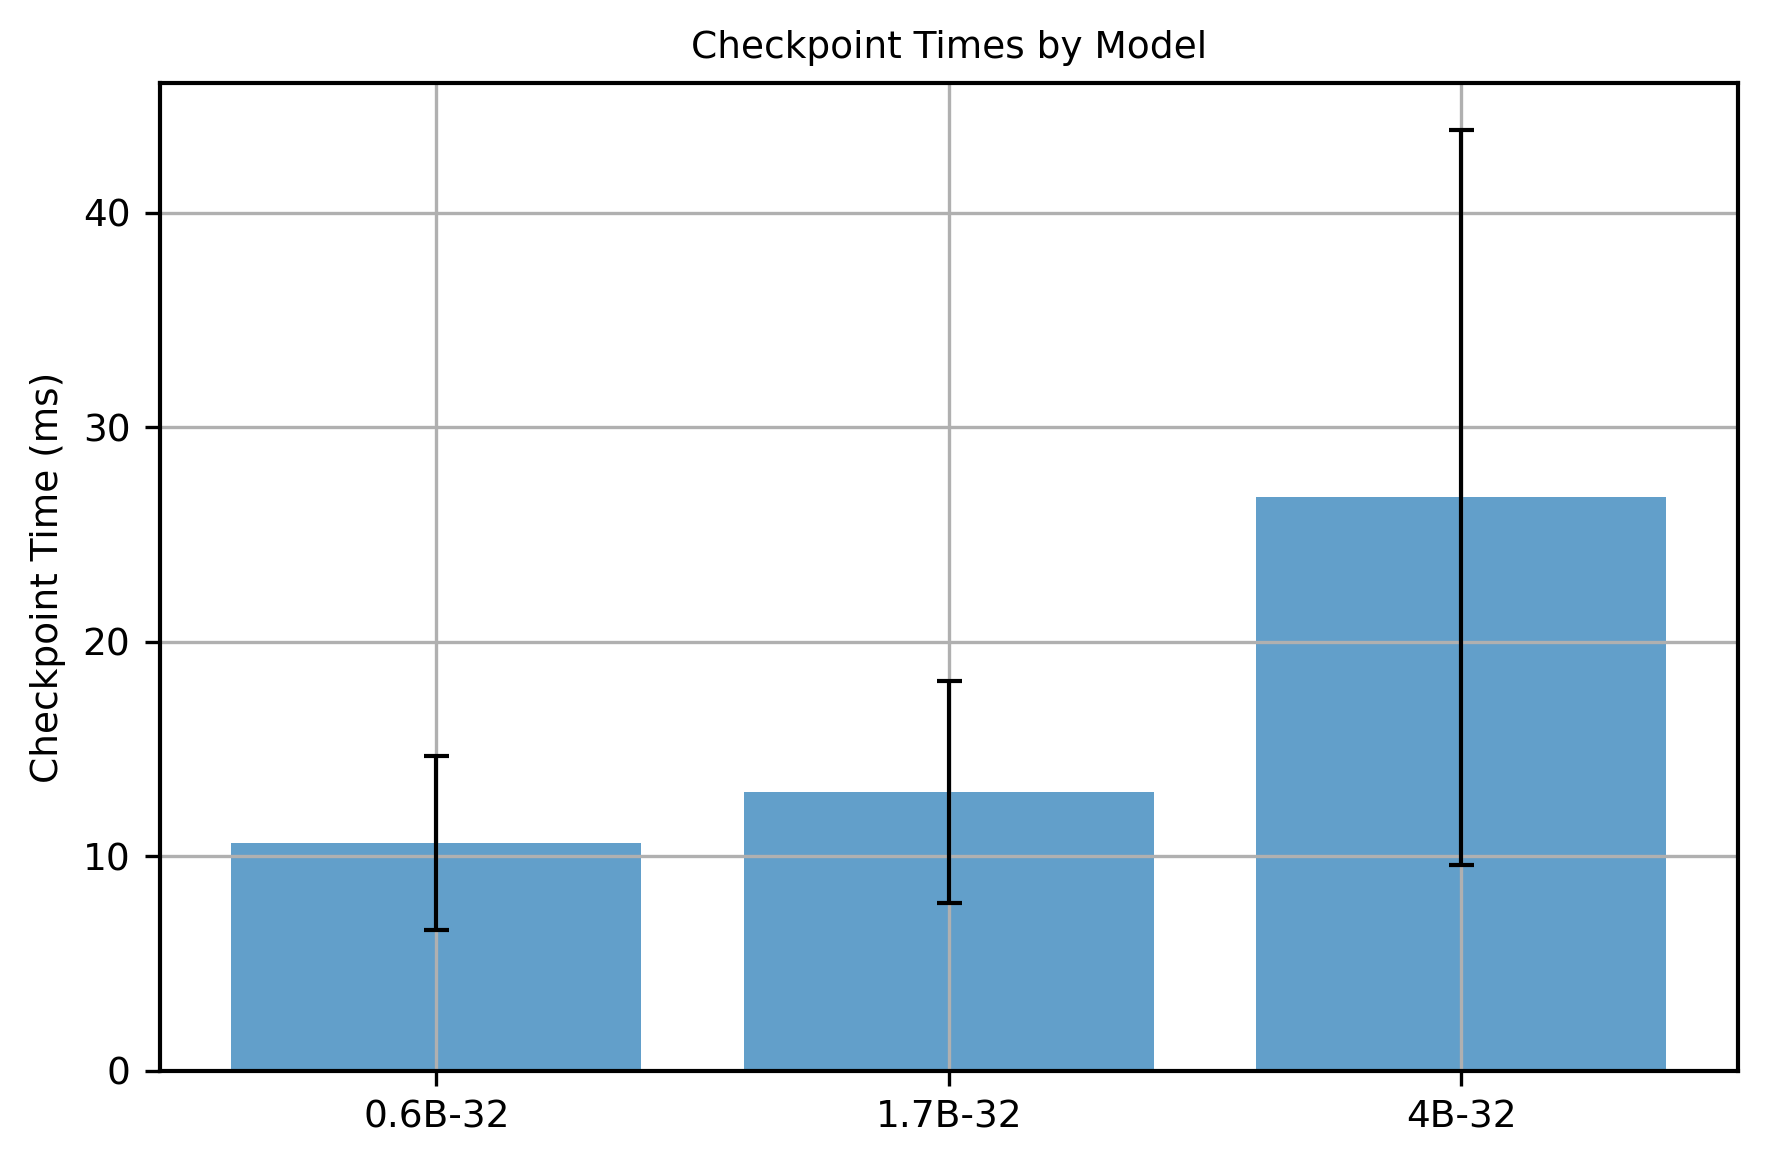

Checkpoint Times Summary:
           model       mean        std    min      max
0  Qwen3-0.6B-32  10.613563   4.041209    3.5   34.953
1  Qwen3-1.7B-32  13.010868   5.165159  3.563   28.741
2    Qwen3-4B-32  26.731098  17.124264  3.716  217.103


In [9]:
# Compare checkpoint times
fig, ax = plt.subplots(figsize=(6, 4))

checkpoint_summary = checkpoint_all.groupby('model')['duration_ms'].agg(['mean', 'std', 'min', 'max']).reset_index()
checkpoint_summary = checkpoint_summary.sort_values('mean')

x_pos = np.arange(len(checkpoint_summary))
ax.bar(x_pos, checkpoint_summary['mean'], yerr=checkpoint_summary['std'], 
       capsize=3, alpha=0.7, color='C0')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels)
ax.set_ylabel('Checkpoint Time (ms)')
ax.set_title('Checkpoint Times by Model')
plt.tight_layout()
plt.show()

print("Checkpoint Times Summary:")
print(checkpoint_summary)

TypeError: boolean value of NA is ambiguous

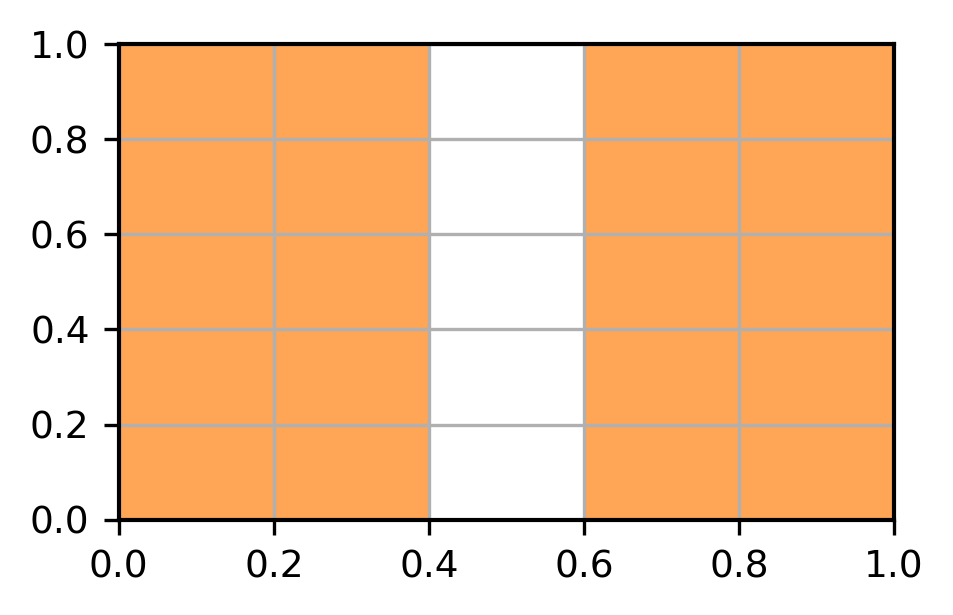

In [10]:
# Compare model loading times
fig, ax = plt.subplots(figsize=figsize)

model_load_summary = model_load_all.groupby('model')['duration_ms'].agg(['mean', 'std', 'min', 'max']).reset_index()
model_load_summary = model_load_summary.sort_values('mean')

x_pos = np.arange(len(model_load_summary))
ax.bar(x_pos, model_load_summary['mean'], yerr=model_load_summary['std'], 
       capsize=3, alpha=0.7, color='C1')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_load_summary['model'], rotation=45, ha='right')
ax.set_ylabel('Model Loading Time (ms)')
ax.set_title('Model Loading Times by Model')
plt.tight_layout()
plt.show()

print("Model Loading Times Summary:")
print(model_load_summary)

In [ ]:
# Compare per-layer inference times
# Group by model and layer_idx, then compute average per layer
layer_summary = layer_all.groupby(['model', 'layer_idx'])['duration_ms'].mean().reset_index()

fig, ax = plt.subplots(figsize=figsize)

for i, model in enumerate(models):
    model_layers = layer_summary[layer_summary['model'] == model]
    ax.plot(model_layers['layer_idx'], model_layers['duration_ms'], 
            marker=marker_list[i % len(marker_list)], 
            linestyle=linestyles[i % len(linestyles)],
            label=model, linewidth=1.5, markersize=4)

ax.set_xlabel('Layer Index')
ax.set_ylabel('Average Layer Inference Time (ms)')
ax.set_title('Per-Layer Inference Times by Model')
ax.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print("Per-Layer Inference Times Summary:")
for model in models:
    model_layers = layer_summary[layer_summary['model'] == model]
    print(f"\n{model}:")
    print(f"  Mean: {model_layers['duration_ms'].mean():.2f} ms")
    print(f"  Std: {model_layers['duration_ms'].std():.2f} ms")
    print(f"  Min: {model_layers['duration_ms'].min():.2f} ms")
    print(f"  Max: {model_layers['duration_ms'].max():.2f} ms")
    print(f"  Total layers: {len(model_layers)}")

In [ ]:
# Overall comparison: total inference time per model (sum of all layer times)
total_inference = layer_all.groupby('model')['duration_ms'].sum().reset_index()
total_inference.columns = ['model', 'total_inference_ms']

# Combine all metrics for side-by-side comparison
comparison = pd.merge(
    checkpoint_summary[['model', 'mean']].rename(columns={'mean': 'checkpoint_ms'}),
    model_load_summary[['model', 'mean']].rename(columns={'mean': 'model_load_ms'}),
    on='model'
)
comparison = pd.merge(
    comparison,
    total_inference,
    on='model'
)

print("Overall Comparison:")
print(comparison.to_string(index=False))

In [ ]:
# Create a combined comparison plot
fig, axes = plt.subplots(1, 3, figsize=(full_width, default_height))

# Checkpoint times
checkpoint_summary = checkpoint_summary.sort_values('mean')
x_pos = np.arange(len(checkpoint_summary))
axes[0].bar(x_pos, checkpoint_summary['mean'], yerr=checkpoint_summary['std'], 
            capsize=3, alpha=0.7, color='C0')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(checkpoint_summary['model'], rotation=45, ha='right')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Checkpoint Times')

# Model loading times
model_load_summary = model_load_summary.sort_values('mean')
x_pos = np.arange(len(model_load_summary))
axes[1].bar(x_pos, model_load_summary['mean'], yerr=model_load_summary['std'], 
            capsize=3, alpha=0.7, color='C1')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_load_summary['model'], rotation=45, ha='right')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Model Loading Times')

# Average layer inference time
layer_avg = layer_all.groupby('model')['duration_ms'].agg(['mean', 'std']).reset_index()
layer_avg = layer_avg.sort_values('mean')
x_pos = np.arange(len(layer_avg))
axes[2].bar(x_pos, layer_avg['mean'], yerr=layer_avg['std'], 
            capsize=3, alpha=0.7, color='C2')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(layer_avg['model'], rotation=45, ha='right')
axes[2].set_ylabel('Time (ms)')
axes[2].set_title('Avg Layer Inference Time')

plt.tight_layout()
plt.show()